<a href="https://colab.research.google.com/github/rankhlove-sys/IBM_CERTIFICAT_PROJET_FINAL/blob/main/CAPSTONE_PROJET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip uninstall -y ipython-sql sqlalchemy
!pip install sqlalchemy==1.4.46
!pip install ipython-sql==0.3.9 prettytable

Found existing installation: ipython-sql 0.5.0
Uninstalling ipython-sql-0.5.0:
  Successfully uninstalled ipython-sql-0.5.0
Found existing installation: SQLAlchemy 2.0.50
Uninstalling SQLAlchemy-2.0.50:
  Successfully uninstalled SQLAlchemy-2.0.50
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 96.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for sqlalchemy: filename=SQLAlchemy-1.4.46-cp312-cp312-linux_x86_64.whl size=1610898 sha256=e4e12d55157fee969094bb57848ae140f0f48d9e5f202740099abe7e273d9be7
  Stored in directory: /root/.cache/pip/wheels/02/a2/82/ea179f8d421288f49b068fc735deb487f017b91a35651fc0d0
Successfully built sqlalchemy
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires sqlalchemy<3.0.0,>=2.0, but you have sqlalchemy 1.4.46 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
!pip uninstall -y ipython-sql
!pip install ipython-sql prettytable

Found existing installation: ipython-sql 0.3.9
Uninstalling ipython-sql-0.3.9:
  Successfully uninstalled ipython-sql-0.3.9
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 56.6 MB/s eta 0:00:00
  Attempting uninstall: sqlalchemy
    Found existing installation: SQLAlchemy 1.4.46
    Uninstalling SQLAlchemy-1.4.46:
      Successfully uninstalled SQLAlchemy-1.4.46


In [4]:
%reload_ext sql

In [5]:
import csv, sqlite3
import prettytable
prettytable.DEFAULT = 'DEFAULT'

con = sqlite3.connect("my_data1.db")
cur = con.cursor()

In [6]:
!pip install -q pandas

In [7]:
%sql sqlite:///my_data1.db

In [8]:
import pandas as pd
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_2/data/Spacex.csv")
df.to_sql("SPACEXTBL", con, if_exists='replace', index=False,method="multi")

101

In [9]:
#DROP THE TABLE IF EXISTS

%sql DROP TABLE IF EXISTS SPACEXTABLE;

 * sqlite:///my_data1.db
Done.


[]

In [10]:
%sql create table SPACEXTABLE as select * from SPACEXTBL where Date is not null

 * sqlite:///my_data1.db
Done.


[]

In [11]:
# TASK1
# Afficher les noms des sites de lancement uniques de la mission spatiale
%%sql
SELECT DISTINCT "Launch_Site"
FROM SPACEXTABLE;

 * sqlite:///my_data1.db
Done.


Launch_Site
CCAFS LC-40
VAFB SLC-4E
KSC LC-39A
CCAFS SLC-40


In [12]:
%%sql
-- TASK 2
-- Afficher 5 enregistrements où les sites de lancement commencent par la chaîne « CCA »
SELECT *
FROM SPACEXTABLE
WHERE "Launch_Site" LIKE 'CCA%'
LIMIT 5;

 * sqlite:///my_data1.db
Done.


Date,Time (UTC),Booster_Version,Launch_Site,Payload,PAYLOAD_MASS__KG_,Orbit,Customer,Mission_Outcome,Landing_Outcome
2010-06-04,18:45:00,F9 v1.0 B0003,CCAFS LC-40,Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success,Failure (parachute)
2010-12-08,15:43:00,F9 v1.0 B0004,CCAFS LC-40,"Dragon demo flight C1, two CubeSats, barrel of Brouere cheese",0,LEO (ISS),NASA (COTS) NRO,Success,Failure (parachute)
2012-05-22,7:44:00,F9 v1.0 B0005,CCAFS LC-40,Dragon demo flight C2,525,LEO (ISS),NASA (COTS),Success,No attempt
2012-10-08,0:35:00,F9 v1.0 B0006,CCAFS LC-40,SpaceX CRS-1,500,LEO (ISS),NASA (CRS),Success,No attempt
2013-03-01,15:10:00,F9 v1.0 B0007,CCAFS LC-40,SpaceX CRS-2,677,LEO (ISS),NASA (CRS),Success,No attempt


In [13]:
%%sql
-- TASK 3
-- Afficher la masse totale de la charge utile transportée par les boosters lancés par la NASA (CRS)
SELECT SUM("PAYLOAD_MASS__KG_") AS "Total_Payload_Mass_NASA_CRS"
FROM SPACEXTABLE
WHERE "Customer" = 'NASA (CRS)';

 * sqlite:///my_data1.db
Done.


Total_Payload_Mass_NASA_CRS
45596


In [14]:
%%sql
-- TASK 4
-- Affichage de la masse moyenne de la charge utile transportée par le lanceur version F9 v1.1
SELECT AVG("PAYLOAD_MASS__KG_") AS "Average_Payload_Mass_F9_v1_1"
FROM SPACEXTABLE
WHERE "Booster_Version" LIKE 'F9 v1.1%';

 * sqlite:///my_data1.db
Done.


Average_Payload_Mass_F9_v1_1
2534.6666666666665


In [15]:
%%sql
-- TASK 5
-- Lister la date du premier atterrissage réussi sur une plateforme terrestre (Ground Pad)
SELECT MIN("Date") AS "First_Successful_Ground_Pad_Landing"
FROM SPACEXTABLE
WHERE "Landing_Outcome" = 'Success (ground pad)';

 * sqlite:///my_data1.db
Done.


First_Successful_Ground_Pad_Landing
2015-12-22


In [16]:
%%sql
-- TASK 6
-- Lister les boosters qui ont réussi avec succès un atterrissage sur un navire-drone (drone ship)
-- et dont la masse de la charge utile est comprise entre 4000 et 6000 kg
SELECT DISTINCT "Booster_Version"
FROM SPACEXTABLE
WHERE "Landing_Outcome" = 'Success (drone ship)'
AND "PAYLOAD_MASS__KG_" BETWEEN 4000 AND 6000;

 * sqlite:///my_data1.db
Done.


Booster_Version
F9 FT B1022
F9 FT B1026
F9 FT B1021.2
F9 FT B1031.2


In [17]:
%%sql
-- TASK 7
-- Lister le nombre total de missions réussies et échouées
SELECT "Mission_Outcome", COUNT(*) AS "Total_Count"
FROM SPACEXTABLE
GROUP BY "Mission_Outcome";

 * sqlite:///my_data1.db
Done.


Mission_Outcome,Total_Count
Failure (in flight),1
Success,98
Success,1
Success (payload status unclear),1


In [18]:
%%sql
-- TASK 8
-- Lister les noms des versions de boosters qui ont transporté la masse de charge utile maximale
SELECT DISTINCT "Booster_Version"
FROM SPACEXTABLE
WHERE "PAYLOAD_MASS__KG_" = (SELECT MAX("PAYLOAD_MASS__KG_") FROM SPACEXTABLE);

 * sqlite:///my_data1.db
Done.


Booster_Version
F9 B5 B1048.4
F9 B5 B1049.4
F9 B5 B1051.3
F9 B5 B1056.4
F9 B5 B1048.5
F9 B5 B1051.4
F9 B5 B1049.5
F9 B5 B1060.2
F9 B5 B1058.3
F9 B5 B1051.6


In [19]:
%%sql
-- TASK 9
-- Lister les records d'échec sur drone ship pour l'année 2015
SELECT substr(Date, 6, 2) AS "Month", "Landing_Outcome", "Booster_Version", "Launch_Site"
FROM SPACEXTABLE
WHERE "Landing_Outcome" = 'Failure (drone ship)'
AND substr(Date, 1, 4) = '2015';

 * sqlite:///my_data1.db
Done.


Month,Landing_Outcome,Booster_Version,Launch_Site
01,Failure (drone ship),F9 v1.1 B1012,CCAFS LC-40
04,Failure (drone ship),F9 v1.1 B1015,CCAFS LC-40


In [20]:
%%sql
-- TASK 10
-- Classer le compte des résultats d'atterrissage entre 2010-06-04 et 2017-03-20 par ordre décroissant
SELECT "Landing_Outcome", COUNT(*) AS "Outcome_Count"
FROM SPACEXTABLE
WHERE "Date" BETWEEN '2010-06-04' AND '2017-03-20'
GROUP BY "Landing_Outcome"
ORDER BY "Outcome_Count" DESC;

 * sqlite:///my_data1.db
Done.


Landing_Outcome,Outcome_Count
No attempt,10
Success (drone ship),5
Failure (drone ship),5
Success (ground pad),3
Controlled (ocean),3
Uncontrolled (ocean),2
Failure (parachute),2
Precluded (drone ship),1


In [21]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib

In [22]:
# andas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

In [23]:
df=pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# If you were unable to complete the previous lab correctly you can uncomment and load this csv

# df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/dataset_part_2.csv')

df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


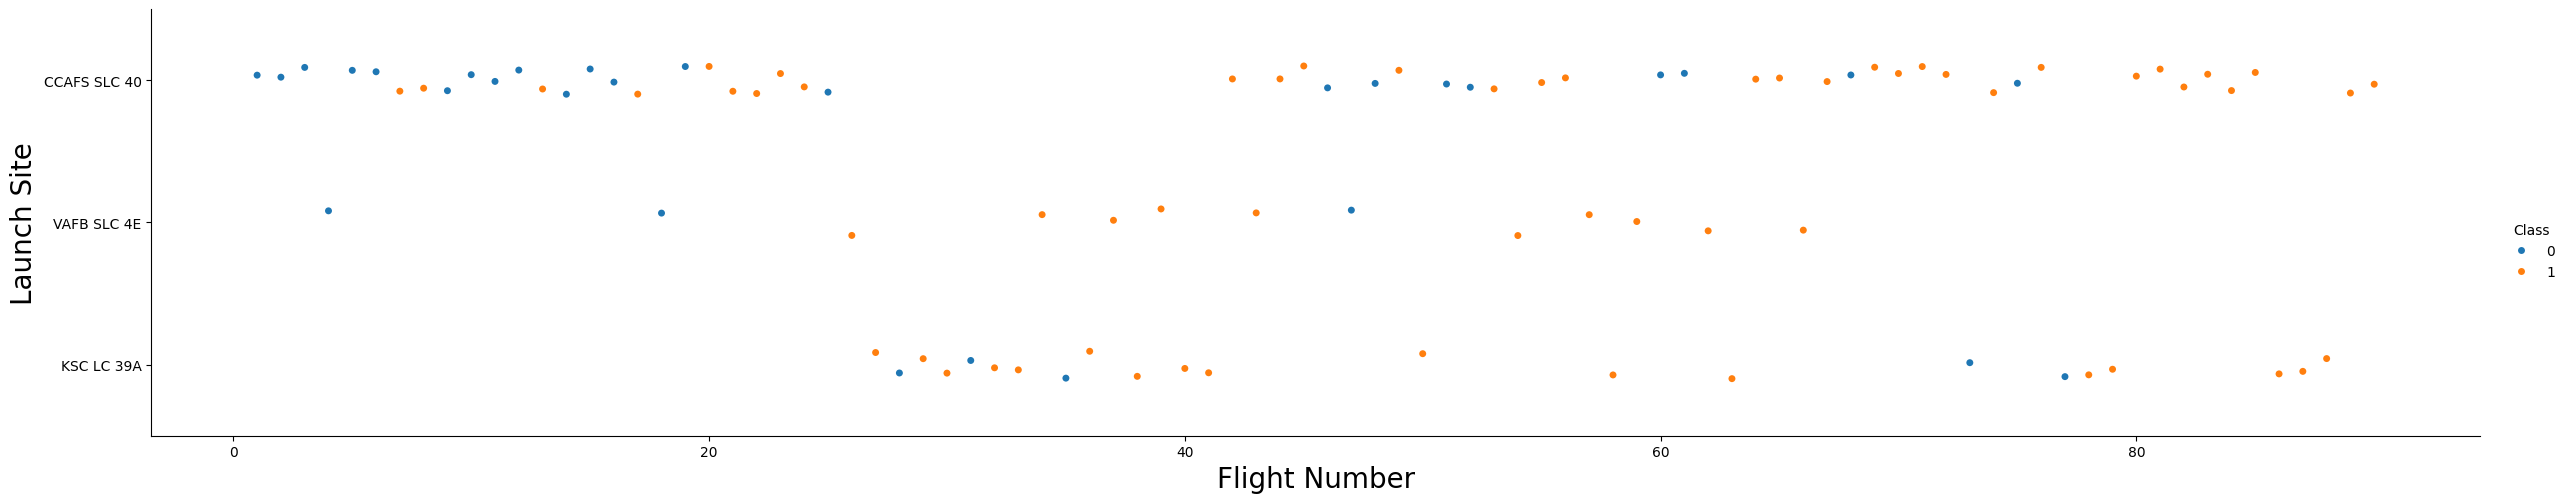

In [24]:
### TASK 1: Visualize the relationship between Flight Number and Launch Site
sns.catplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Launch Site",fontsize=20)
plt.show()

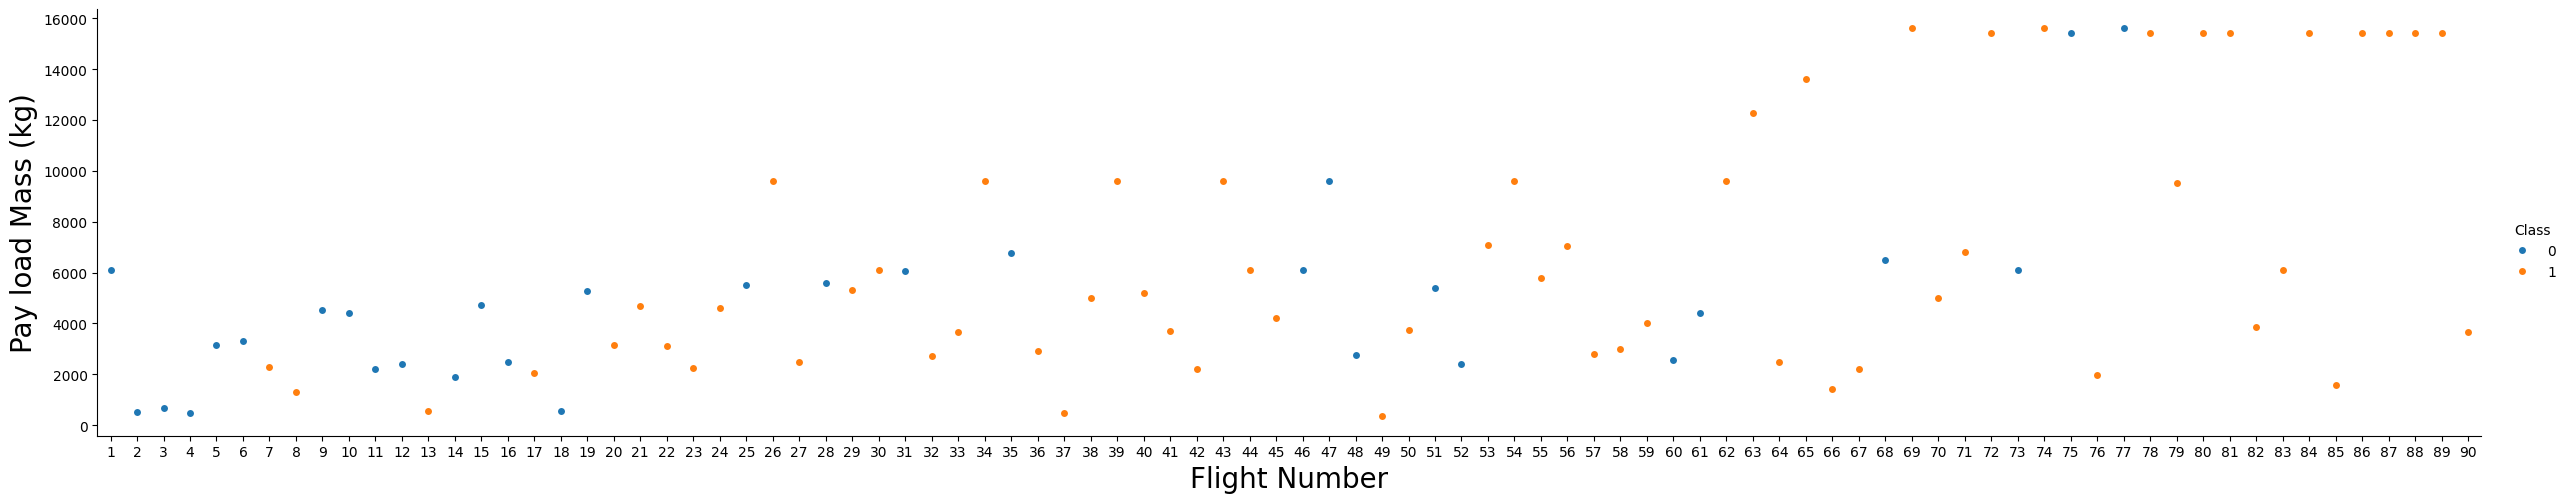

In [25]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

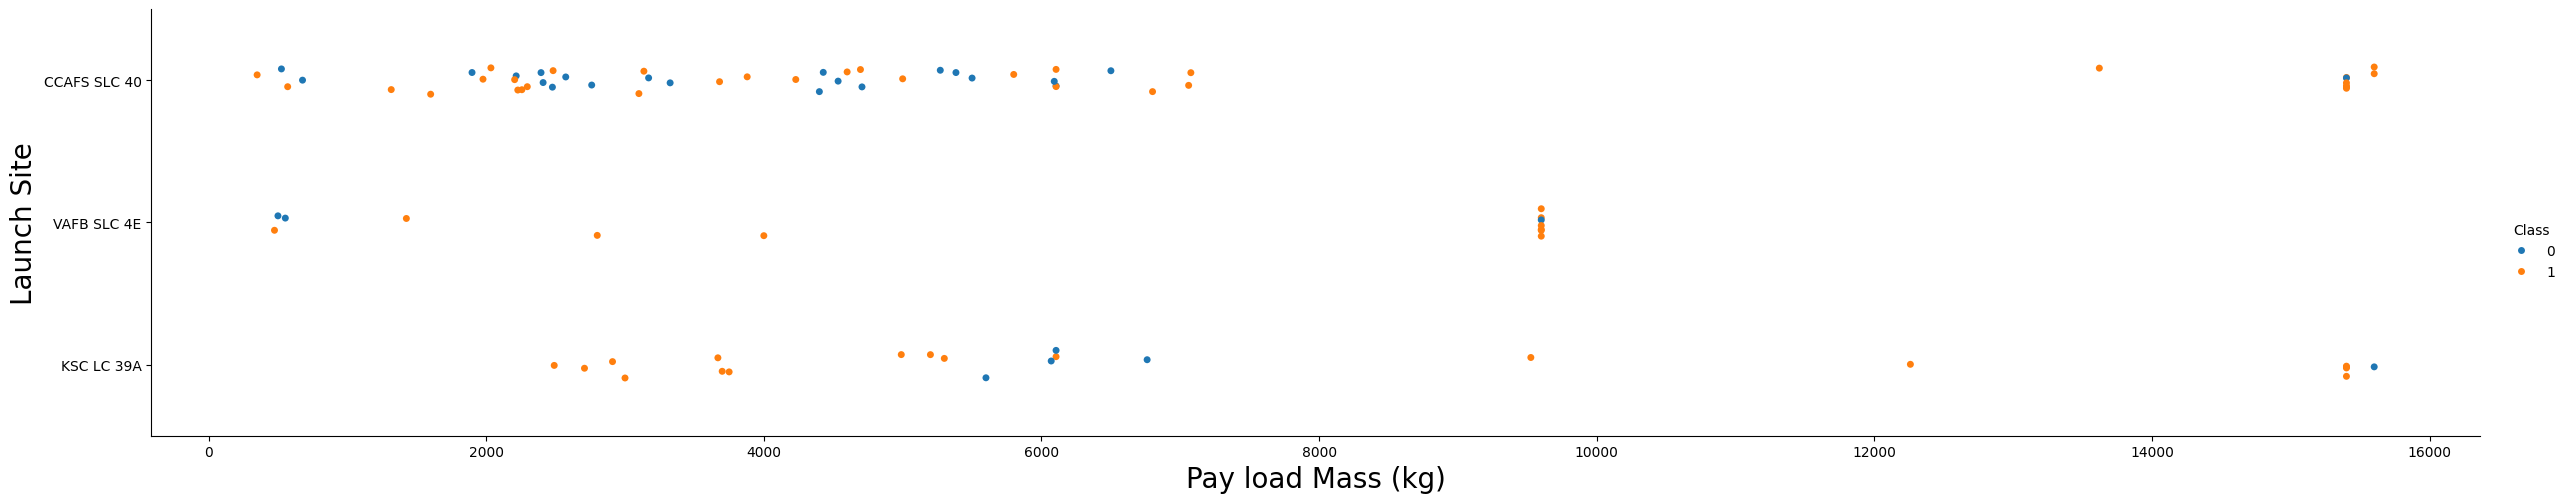

In [26]:
### TASK 2: Visualize the relationship between Payload and Launch Site
sns.catplot(y="LaunchSite", x="PayloadMass", hue="Class", data=df, aspect = 5)
plt.xlabel("Pay load Mass (kg)",fontsize=20)
plt.ylabel("Launch Site",fontsize=20)
plt.show()

/tmp/ipykernel_482/2716640950.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Orbit", y="Class", data=df_orbit, palette='viridis')


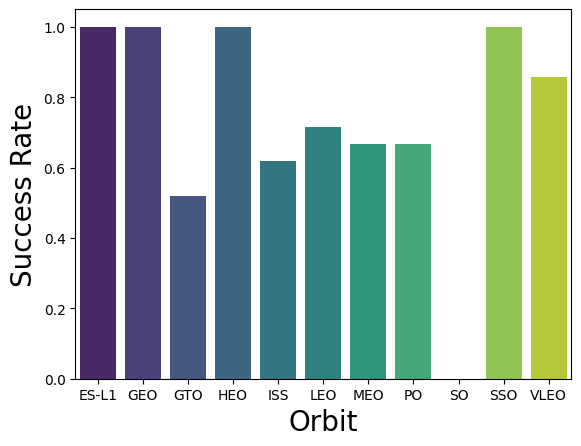

In [27]:
### TASK 3: Visualize the relationship between success rate of each orbit type
import pandas as pd
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")
df_orbit = df.groupby('Orbit')['Class'].mean().reset_index()
sns.barplot(x="Orbit", y="Class", data=df_orbit, palette='viridis')
plt.xlabel("Orbit",fontsize=20)
plt.ylabel("Success Rate",fontsize=20)
plt.show()

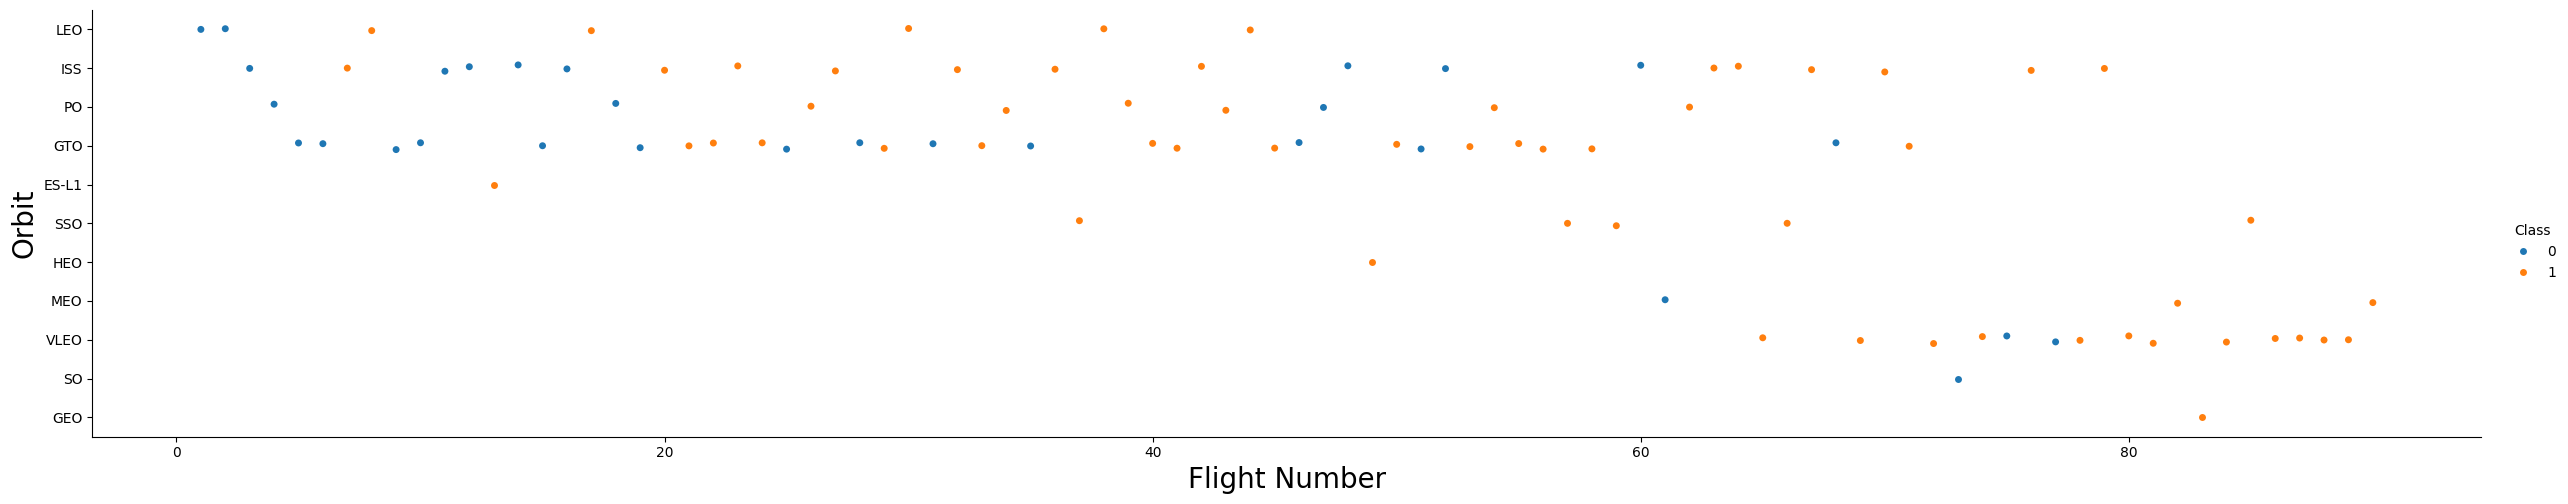

In [28]:
### TASK 4: Visualize the relationship between FlightNumber and Orbit type
sns.catplot(y="Orbit", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Orbit",fontsize=20)
plt.show()

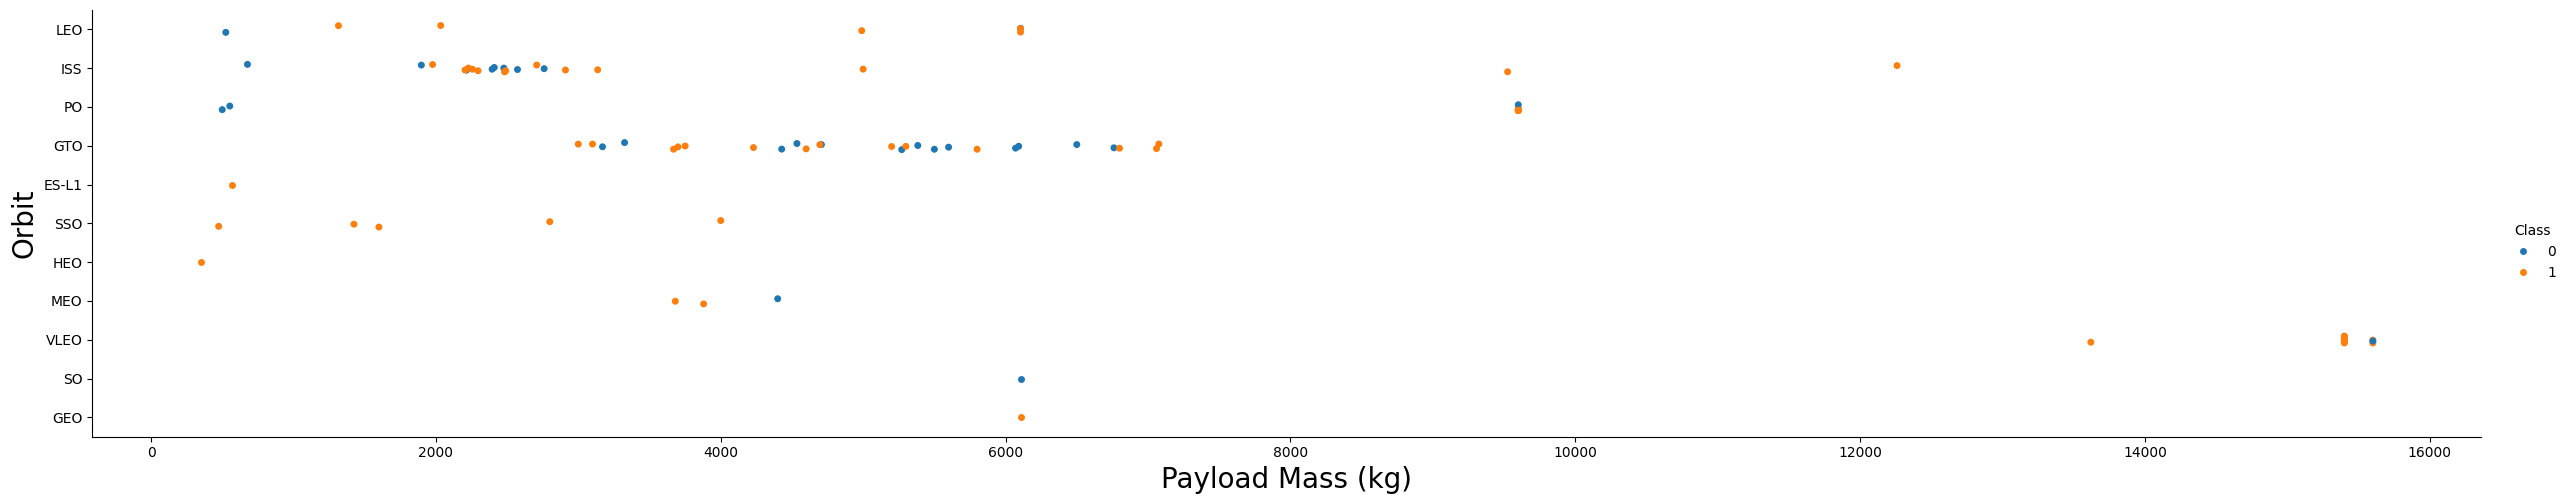

In [29]:
### TASK 5: Visualize the relationship between Payload and Orbit type
sns.catplot(y="Orbit", x="PayloadMass", hue="Class", data=df, aspect = 5)
plt.xlabel("Payload Mass (kg)",fontsize=20)
plt.ylabel("Orbit",fontsize=20)
plt.show()

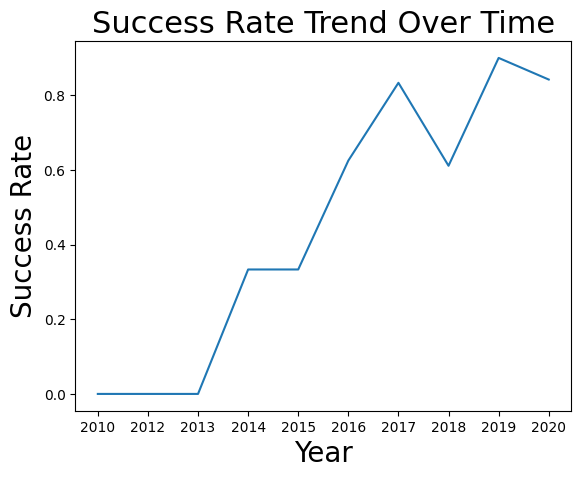

In [30]:
### TASK 6: Visualize the launch success yearly trend

# A function to Extract years from the date
year=[]
def Extract_year(date):
    for i in date:
        year.append(i.split("-")[0])
    return year

Extract_year(df["Date"])
df['Year'] = year

# Plot a line chart with x axis to be the extracted year and y axis to be the success rate
df_year = df.groupby('Year')['Class'].mean().reset_index()

sns.lineplot(x="Year", y="Class", data=df_year)
plt.xlabel("Year",fontsize=20)
plt.ylabel("Success Rate",fontsize=20)
plt.title("Success Rate Trend Over Time", fontsize=22)
plt.show()

In [31]:
### TASK 7: Create dummy variables for categorical columns
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]

# HINT: Use get_dummies() function on the categorical columns
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])

### TASK 8: Cast all numeric columns to `float64`
features_one_hot = features_one_hot.astype('float64')

print(features_one_hot.head())
print(f"Total features after one-hot encoding: {features_one_hot.shape[1]}")

   FlightNumber  PayloadMass  Flights  GridFins  Reused  Legs  Block  \
0           1.0  6104.959412      1.0       0.0     0.0   0.0    1.0   
1           2.0   525.000000      1.0       0.0     0.0   0.0    1.0   
2           3.0   677.000000      1.0       0.0     0.0   0.0    1.0   
3           4.0   500.000000      1.0       0.0     0.0   0.0    1.0   
4           5.0  3170.000000      1.0       0.0     0.0   0.0    1.0   

   ReusedCount  Orbit_ES-L1  Orbit_GEO  ...  Serial_B1048  Serial_B1049  \
0          0.0          0.0        0.0  ...           0.0           0.0   
1          0.0          0.0        0.0  ...           0.0           0.0   
2          0.0          0.0        0.0  ...           0.0           0.0   
3          0.0          0.0        0.0  ...           0.0           0.0   
4          0.0          0.0        0.0  ...           0.0           0.0   

   Serial_B1050  Serial_B1051  Serial_B1054  Serial_B1056  Serial_B1058  \
0           0.0           0.0           0

In [32]:
### TASK 8: Export the data to a CSV
features_one_hot.to_csv('dataset_part_3.csv', index=False)
print("Data exported successfully to 'dataset_part_3.csv'")

Data exported successfully to 'dataset_part_3.csv'


In [33]:
!pip3 install folium
!pip3 install wget
!pip3 install pandas

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=3d8db365ea8ef2b04c23b793b2f3248197a967d29b536e1f87b4913bac9d181e
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [34]:
import folium
import wget
import pandas as pd

In [35]:
# Import folium MarkerCluster plugin
from folium.plugins import MarkerCluster
# Import folium MousePosition plugin
from folium.plugins import MousePosition
# Import folium DivIcon plugin
from folium.features import DivIcon

In [36]:
# Download and read the `spacex_launch_geo.csv`
spacex_csv_file = wget.download('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_geo.csv')
spacex_df=pd.read_csv(spacex_csv_file)

In [37]:
# Select relevant sub-columns: `Launch Site`, `Lat(Latitude)`, `Long(Longitude)`, `class`
spacex_df = spacex_df[['Launch Site', 'Lat', 'Long', 'class']]
launch_sites_df = spacex_df.groupby(['Launch Site'], as_index=False).first()
launch_sites_df = launch_sites_df[['Launch Site', 'Lat', 'Long']]
launch_sites_df

,Launch Site,Lat,Long
0,CCAFS LC-40,28.562302,-80.577356
1,CCAFS SLC-40,28.563197,-80.576820
2,KSC LC-39A,28.573255,-80.646895
3,VAFB SLC-4E,34.632834,-120.610745


In [38]:
# Start location is NASA Johnson Space Center
nasa_coordinate = [29.559684888503615, -95.0830971930759]
site_map = folium.Map(location=nasa_coordinate, zoom_start=10)

In [39]:
# Create a blue circle at NASA Johnson Space Center's coordinate with a popup label showing its name
circle = folium.Circle(nasa_coordinate, radius=1000, color='#d35400', fill=True).add_child(folium.Popup('NASA Johnson Space Center'))
# Create a blue circle at NASA Johnson Space Center's coordinate with a icon showing its name
marker = folium.map.Marker(
    nasa_coordinate,
    # Create an icon as a text label
    icon=DivIcon(
        icon_size=(20,20),
        icon_anchor=(0,0),
        html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % 'NASA JSC',
        )
    )
site_map.add_child(circle)
site_map.add_child(marker)

In [40]:
# Initial the map
site_map = folium.Map(location=nasa_coordinate, zoom_start=5)
# For each launch site, add a Circle object based on its coordinate (Lat, Long) values. In addition, add Launch site name as a popup label


In [41]:
spacex_df.tail(10)

,Launch Site,Lat,Long,class
46,KSC LC-39A,28.573255,-80.646895,1
47,KSC LC-39A,28.573255,-80.646895,1
48,KSC LC-39A,28.573255,-80.646895,1
49,CCAFS SLC-40,28.563197,-80.576820,1
50,CCAFS SLC-40,28.563197,-80.576820,1
51,CCAFS SLC-40,28.563197,-80.576820,0
52,CCAFS SLC-40,28.563197,-80.576820,0
53,CCAFS SLC-40,28.563197,-80.576820,0
54,CCAFS SLC-40,28.563197,-80.576820,1
55,CCAFS SLC-40,28.563197,-80.576820,0


In [42]:
marker_cluster = MarkerCluster()


In [43]:
# Function to assign color to launch outcome
def assign_marker_color(launch_outcome):
    if launch_outcome == 1:
        return 'green'
    else:
        return 'red'

spacex_df['marker_color'] = spacex_df['class'].apply(assign_marker_color)
spacex_df.tail(10)

,Launch Site,Lat,Long,class,marker_color
46,KSC LC-39A,28.573255,-80.646895,1,green
47,KSC LC-39A,28.573255,-80.646895,1,green
48,KSC LC-39A,28.573255,-80.646895,1,green
49,CCAFS SLC-40,28.563197,-80.576820,1,green
50,CCAFS SLC-40,28.563197,-80.576820,1,green
51,CCAFS SLC-40,28.563197,-80.576820,0,red
52,CCAFS SLC-40,28.563197,-80.576820,0,red
53,CCAFS SLC-40,28.563197,-80.576820,0,red
54,CCAFS SLC-40,28.563197,-80.576820,1,green
55,CCAFS SLC-40,28.563197,-80.576820,0,red


In [44]:
# Add marker_cluster to current site_map
site_map.add_child(marker_cluster)

# for each row in spacex_df data frame
# create a Marker object with its coordinate
# and customize the Marker's icon property to indicate if this launch was successed or failed,
# e.g., icon=folium.Icon(color='white', icon_color=row['marker_color']
for index, record in spacex_df.iterrows():
    # TODO: Create and add a Marker cluster to the site map
    # marker = folium.Marker(...)
    marker_cluster.add_child(marker)

site_map

In [45]:
### TASK 3: Calculate the distances between a launch site to its proximities

# Add Mouse Position to determine the coordinate of a point on the map
formatter = "function(num) {return L.Util.formatNum(num, 5);};"
mouse_position = MousePosition(
    position='topright',
    separator=' Long: ',
    empty_string='NaN',
    lng_first=False,
    num_digits=20,
    prefix='Lat:',
    lat_formatter=formatter,
    lng_formatter=formatter,
)

site_map.add_child(mouse_position)
site_map

In [46]:
from math import sin, cos, sqrt, atan2, radians

def calculate_distance(lat1, lon1, lat2, lon2):
    # approximate radius of earth in km
    R = 6373.0

    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    distance = R * c
    return distance

In [47]:
# distance_coastline = calculate_distance(launch_site_lat, launch_site_lon, coastline_lat, coastline_lon)
launch_site_lat = 28.573255
launch_site_lon = -80.646895
coastline_lat = 28.56367
coastline_lon = -80.56763
distance_coastline = calculate_distance(launch_site_lat, launch_site_lon, coastline_lat, coastline_lon)

# Create and add a folium.Marker on your selected closest coastline point on the map
# Display the distance between coastline point and launch site using the icon property
distance_marker = folium.Marker(
   [coastline_lat, coastline_lon],
   icon=DivIcon(
       icon_size=(20,20),
       icon_anchor=(0,0),
       html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % "{:10.2f} KM".format(distance_coastline),
       )
   )
site_map.add_child(distance_marker)

# Create a `folium.PolyLine` object using the coastline coordinates and launch site coordinate
lines=folium.PolyLine(locations=[[launch_site_lat, launch_site_lon], [coastline_lat, coastline_lon]], weight=1)
site_map.add_child(lines)
site_map

In [48]:
# Example: Distance to Railway and Highway
railway_lat, railway_lon = 28.57325, -80.65411
highway_lat, highway_lon = 28.57325, -80.65545

distance_railway = calculate_distance(launch_site_lat, launch_site_lon, railway_lat, railway_lon)
distance_highway = calculate_distance(launch_site_lat, launch_site_lon, highway_lat, highway_lon)

# Add Railway Marker
folium.Marker([railway_lat, railway_lon], icon=DivIcon(icon_size=(20,20),icon_anchor=(0,0),html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % "{:10.2f} KM".format(distance_railway))).add_to(site_map)
folium.PolyLine(locations=[[launch_site_lat, launch_site_lon], [railway_lat, railway_lon]], weight=1, color='green').add_to(site_map)

# Add Highway Marker
folium.Marker([highway_lat, highway_lon], icon=DivIcon(icon_size=(20,20),icon_anchor=(0,0),html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % "{:10.2f} KM".format(distance_highway))).add_to(site_map)
folium.PolyLine(locations=[[launch_site_lat, launch_site_lon], [highway_lat, highway_lon]], weight=1, color='blue').add_to(site_map)

site_map

In [49]:
# Distance to the nearest city (Titusville)
city_lat, city_lon = 28.61205, -80.80755
distance_city = calculate_distance(launch_site_lat, launch_site_lon, city_lat, city_lon)

# Add City Marker
folium.Marker(
    [city_lat, city_lon],
    icon=DivIcon(
        icon_size=(20,20),
        icon_anchor=(0,0),
        html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % "{:10.2f} KM".format(distance_city),
    )
).add_to(site_map)

# Add line to City
folium.PolyLine(locations=[[launch_site_lat, launch_site_lon], [city_lat, city_lon]], weight=1, color='red').add_to(site_map)

site_map

In [50]:
# Distance to the nearest city (Titusville)
city_lat, city_lon = 28.61205, -80.80755
distance_city = calculate_distance(launch_site_lat, launch_site_lon, city_lat, city_lon)

# Add City Marker
folium.Marker(
    [city_lat, city_lon],
    icon=DivIcon(
        icon_size=(20,20),
        icon_anchor=(0,0),
        html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % "{:10.2f} KM".format(distance_city),
    )
).add_to(site_map)

# Add line to City
folium.PolyLine(locations=[[launch_site_lat, launch_site_lon], [city_lat, city_lon]], weight=1, color='red').add_to(site_map)

site_map

Now we can use this function to calculate distances to points of interest. For example, let's find the distance from a launch site to the closest coastline.

In [51]:
!pip install numpy
!pip install pandas
!pip install seaborn
!pip install scikit-learn

In [52]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

In [53]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix');
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed'])
    plt.show()

In [54]:
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")
data.head()

X = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')
X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
88,89.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


In [55]:
Y = pd.Series(data['Class'].to_numpy())

# Display the first few entries to verify
display(Y.head())

,0
0,0
1,0
2,0
3,0
4,0


### TASK 2: Standardize the data
Standardize the data in `X` then assign it to the variable `X` using the transform provided below.

In [56]:
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)
display(X[0:5])

array([[-1.71291154e+00, -1.94814463e-16, -6.53912840e-01,
        -1.57589457e+00, -9.73440458e-01, -1.05999788e-01,
        -1.05999788e-01, -6.54653671e-01, -1.05999788e-01,
        -5.51677284e-01,  3.44342023e+00, -1.85695338e-01,
        -3.33333333e-01, -1.05999788e-01, -2.42535625e-01,
        -4.29197538e-01,  7.97724035e-01, -5.68796459e-01,
        -4.10890702e-01, -4.10890702e-01, -1.50755672e-01,
        -7.97724035e-01, -1.50755672e-01, -3.92232270e-01,
         9.43398113e+00, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.50755672e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.50755672e-01, -1.05999788e-0

### TASK 3: Split the data
Use the function `train_test_split` to split the data `X` and `Y` into training and test data. Set the parameter `test_size` to 0.2 and `random_state` to 2.

In [57]:
Y = pd.Series(data['Class'].to_numpy())
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)
print(f"Number of test samples: {Y_test.shape[0]}")

Number of test samples: 18


In [58]:
# TASK 4
parameters ={'C':[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}
lr=LogisticRegression()
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)
print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.8464285714285713


test set accuracy : 0.8333333333333334


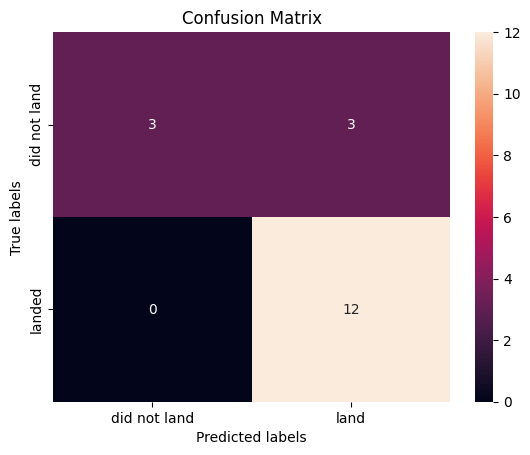

In [59]:
# TASK 5
print("test set accuracy :", logreg_cv.score(X_test, Y_test))
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [60]:
# TASK 6
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn import preprocessing

# Recharger les données si nécessaire
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")
X = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')
Y = data['Class'].to_numpy()

# Standardiser les données X
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

# Division des données
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# Paramètres pour la recherche par grille
parameters = {'kernel':('linear', 'rbf','poly', 'sigmoid'), 'C': np.logspace(-3, 3, 5), 'gamma':np.logspace(-3, 3, 5)}

# Initialisation et entraînement du modèle SVM
svm = SVC()
svm_cv = GridSearchCV(svm, parameters, cv=10)
svm_cv.fit(X_train, Y_train)

# Affichage des résultats
print("tuned hpyerparameters :(best parameters) ", svm_cv.best_params_)
print("accuracy :", svm_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
accuracy : 0.8482142857142856


test set accuracy : 0.8333333333333334


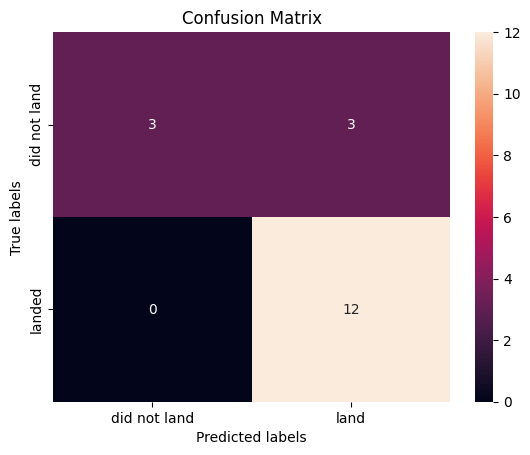

In [61]:
# TASK 7
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix');
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed'])
    plt.show()

# Calculer la précision sur l'ensemble de test
test_accuracy = svm_cv.score(X_test, Y_test)
print("test set accuracy :", test_accuracy)

# Prédire les résultats et afficher la matrice de confusion
yhat = svm_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

In [62]:
# TASK 8
parameters = {'criterion': ['gini', 'entropy'], 'splitter': ['best', 'random'], 'max_depth': [2*n for n in range(1,10)], 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [1, 2, 4], 'min_samples_split': [2, 5, 10]}
tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree, parameters, cv=10)
tree_cv.fit(X_train, Y_train)
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'criterion': 'entropy', 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'best'}
accuracy : 0.8892857142857145


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
3240 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3240 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/u

test set accuracy : 0.8333333333333334


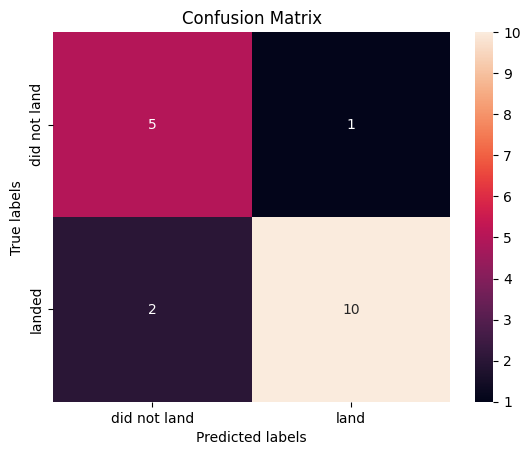

In [63]:
# TASK 9
print("test set accuracy :", tree_cv.score(X_test, Y_test))
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [64]:
# TASK 10
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'], 'p': [1,2]}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, parameters, cv=10)
knn_cv.fit(X_train, Y_train)
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
accuracy : 0.8482142857142858


test set accuracy : 0.8333333333333334


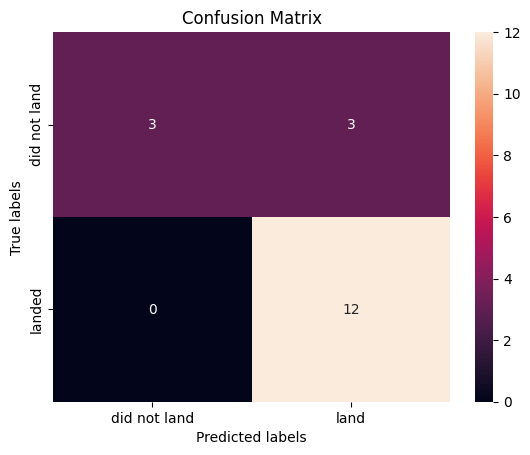

In [65]:
# TASK 11
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Initialize the KNN model and grid search parameters
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'], 'p': [1,2]}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, parameters, cv=10)

# Fit the model
knn_cv.fit(X_train, Y_train)

# Calculate accuracy on the test data for KNN and plot the confusion matrix
knn_test_accuracy = knn_cv.score(X_test, Y_test)
print("test set accuracy :", knn_test_accuracy)

yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

,Method,Train Accuracy,Test Accuracy
0,LogReg,0.846429,0.833333
1,SVM,0.848214,0.833333
2,Tree,0.889286,0.833333
3,KNN,0.848214,0.833333


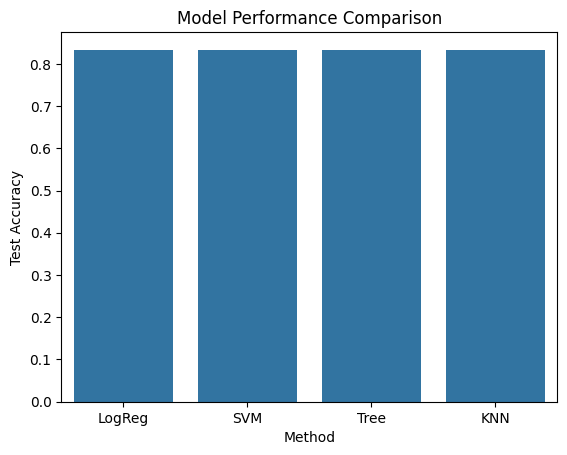

In [66]:
# TASK 12
methods = ["LogReg", "SVM", "Tree", "KNN"]
scores = [logreg_cv.best_score_, svm_cv.best_score_, tree_cv.best_score_, knn_cv.best_score_]
test_scores = [logreg_cv.score(X_test, Y_test), svm_cv.score(X_test, Y_test), tree_cv.score(X_test, Y_test), knn_cv.score(X_test, Y_test)]
comparison_df = pd.DataFrame({"Method": methods, "Train Accuracy": scores, "Test Accuracy": test_scores})
display(comparison_df)
sns.barplot(x="Method", y="Test Accuracy", data=comparison_df)
plt.title("Model Performance Comparison")
plt.show()

In [67]:
parameters ={'C':[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}
lr=LogisticRegression()
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)
print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.8464285714285713


test set accuracy : 0.8333333333333334


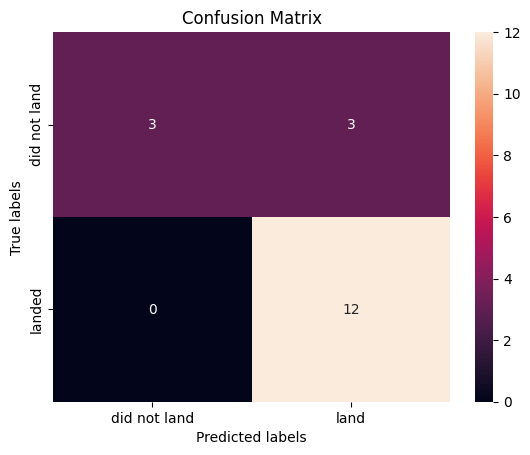

In [68]:
print("test set accuracy :", logreg_cv.score(X_test, Y_test))
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [69]:
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'), 'C': np.logspace(-3, 3, 5), 'gamma':np.logspace(-3, 3, 5)}
svm = SVC()
svm_cv = GridSearchCV(svm, parameters, cv=10)
svm_cv.fit(X_train, Y_train)
print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
accuracy : 0.8482142857142856


test set accuracy : 0.8333333333333334


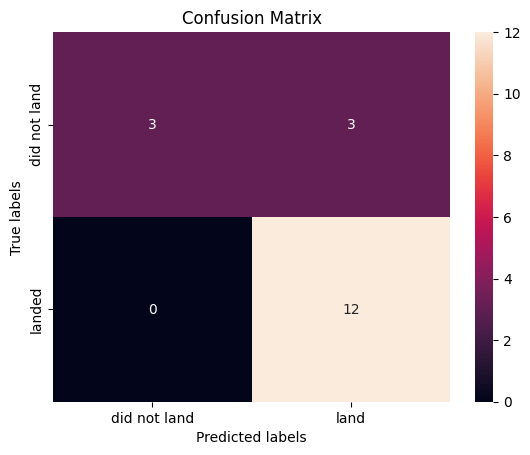

In [70]:
print("test set accuracy :", svm_cv.score(X_test, Y_test))
yhat=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [71]:
parameters = {'criterion': ['gini', 'entropy'], 'splitter': ['best', 'random'], 'max_depth': [2*n for n in range(1,10)], 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [1, 2, 4], 'min_samples_split': [2, 5, 10]}
tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree, parameters, cv=10)
tree_cv.fit(X_train, Y_train)
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'criterion': 'entropy', 'max_depth': 14, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 5, 'splitter': 'random'}
accuracy : 0.8732142857142856


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
3240 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3240 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/u

test set accuracy : 0.7222222222222222


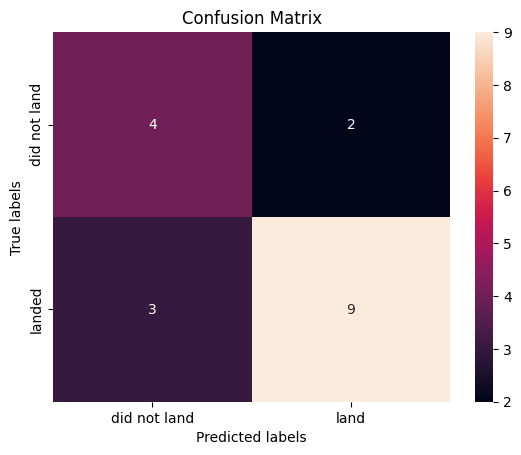

In [72]:
print("test set accuracy :", tree_cv.score(X_test, Y_test))
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [73]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'], 'p': [1,2]}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, parameters, cv=10)
knn_cv.fit(X_train, Y_train)
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
accuracy : 0.8482142857142858


test set accuracy : 0.8333333333333334


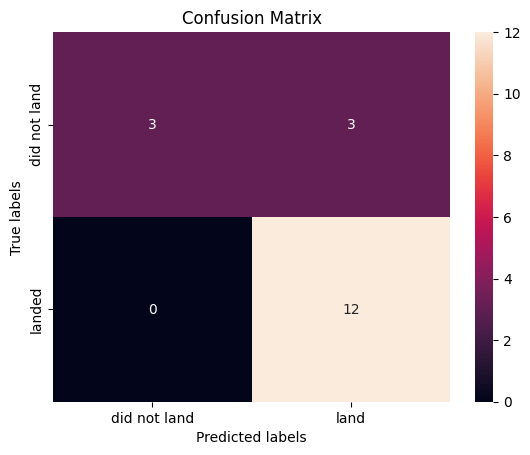

In [74]:
print("test set accuracy :", knn_cv.score(X_test, Y_test))
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

,Method,Train Accuracy,Test Accuracy
0,LogReg,0.846429,0.833333
1,SVM,0.848214,0.833333
2,Tree,0.873214,0.722222
3,KNN,0.848214,0.833333


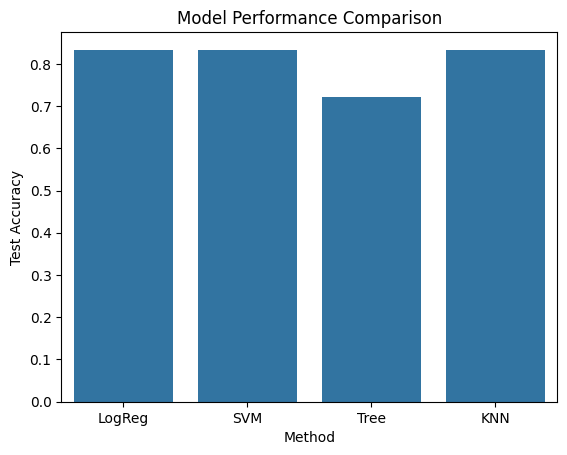

In [75]:
methods = ["LogReg", "SVM", "Tree", "KNN"]
scores = [logreg_cv.best_score_, svm_cv.best_score_, tree_cv.best_score_, knn_cv.best_score_]
test_scores = [logreg_cv.score(X_test, Y_test), svm_cv.score(X_test, Y_test), tree_cv.score(X_test, Y_test), knn_cv.score(X_test, Y_test)]
comparison_df = pd.DataFrame({"Method": methods, "Train Accuracy": scores, "Test Accuracy": test_scores})
display(comparison_df)
sns.barplot(x="Method", y="Test Accuracy", data=comparison_df)
plt.title("Model Performance Comparison")
plt.show()

### TASK 4: Logistic Regression
Create a logistic regression object then create a GridSearchCV object `logreg_cv` with cv = 10. Fit the object to find the best parameters from the dictionary `parameters`.

In [76]:
parameters ={'C':[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}
lr=LogisticRegression()
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)
print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.8464285714285713


### TASK 5: Logistic Regression Accuracy
Calculate the accuracy on the test data using the method `score` and plot the confusion matrix.

test set accuracy : 0.8333333333333334


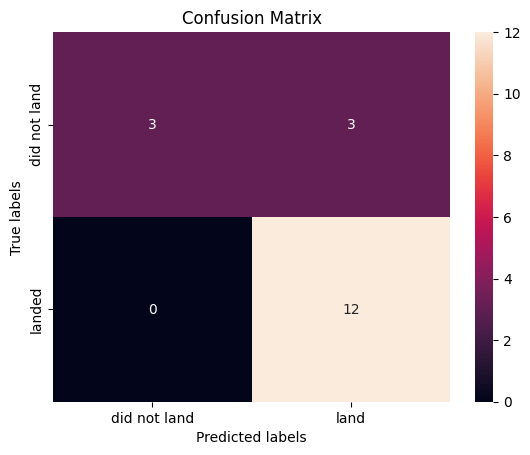

In [77]:
print("test set accuracy :", logreg_cv.score(X_test, Y_test))
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

### TASK 6: Support Vector Machine
Create a support vector machine object then create a GridSearchCV object `svm_cv` with cv = 10. Fit the object to find the best parameters.

In [78]:
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'), 'C': np.logspace(-3, 3, 5), 'gamma':np.logspace(-3, 3, 5)}
svm = SVC()
svm_cv = GridSearchCV(svm, parameters, cv=10)
svm_cv.fit(X_train, Y_train)
print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
accuracy : 0.8482142857142856


### TASK 7: SVM Accuracy
Calculate the accuracy on the test data and plot the confusion matrix.

test set accuracy : 0.8333333333333334


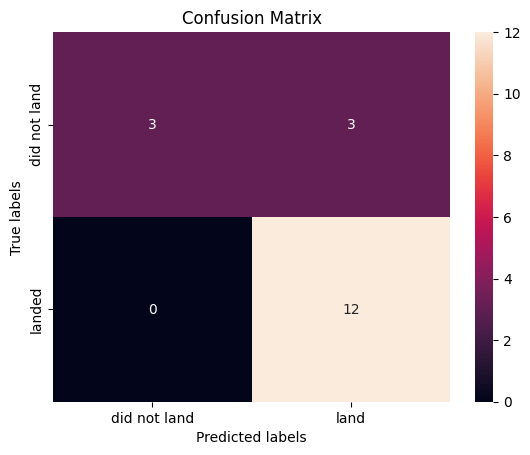

In [79]:
print("test set accuracy :", svm_cv.score(X_test, Y_test))
yhat=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

### TASK 8: Decision Tree
Create a decision tree classifier object then create a GridSearchCV object `tree_cv` with cv = 10. Fit the object to find the best parameters.

In [80]:
parameters = {'criterion': ['gini', 'entropy'], 'splitter': ['best', 'random'], 'max_depth': [2*n for n in range(1,10)], 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [1, 2, 4], 'min_samples_split': [2, 5, 10]}
tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree, parameters, cv=10)
tree_cv.fit(X_train, Y_train)
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'criterion': 'gini', 'max_depth': 18, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'best'}
accuracy : 0.8875


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
3240 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3240 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/u

### TASK 9: Decision Tree Accuracy
Calculate the accuracy on the test data and plot the confusion matrix.

test set accuracy : 0.7777777777777778


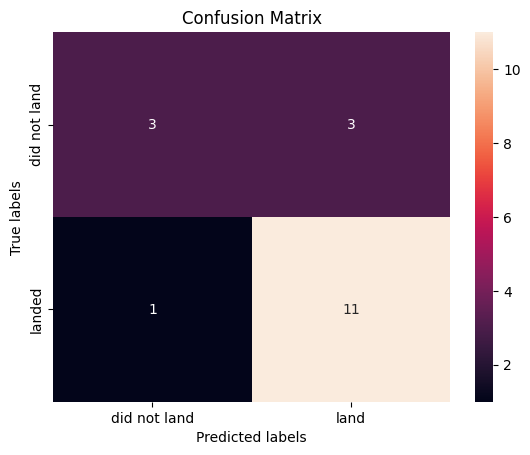

In [81]:
print("test set accuracy :", tree_cv.score(X_test, Y_test))
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

### TASK 10: K-Nearest Neighbors
Create a k-nearest neighbors object then create a GridSearchCV object `knn_cv` with cv = 10. Fit the object to find the best parameters.

In [82]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'], 'p': [1,2]}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, parameters, cv=10)
knn_cv.fit(X_train, Y_train)
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
accuracy : 0.8482142857142858


### TASK 11: KNN Accuracy
Calculate the accuracy on the test data and plot the confusion matrix.

test set accuracy : 0.8333333333333334


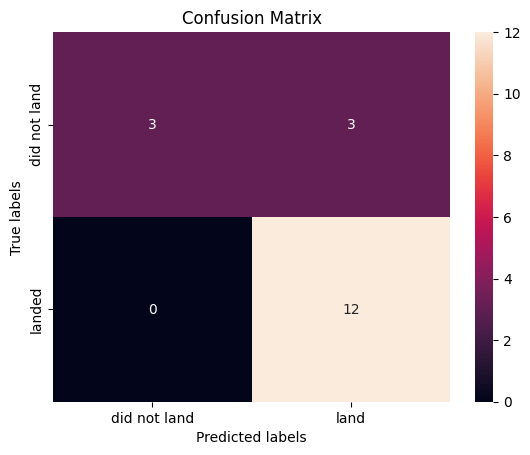

In [83]:
print("test set accuracy :", knn_cv.score(X_test, Y_test))
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

### TASK 12: Model Comparison
Find the method performs best.

Model Performance Comparison:
   Method  Train Accuracy  Test Accuracy
0  LogReg        0.846429       0.833333
1     SVM        0.848214       0.833333
2    Tree        0.860714       0.722222
3     KNN        0.848214       0.833333


/tmp/ipykernel_482/3500931298.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Method', y='Test Accuracy', data=comparison_df, palette='viridis')


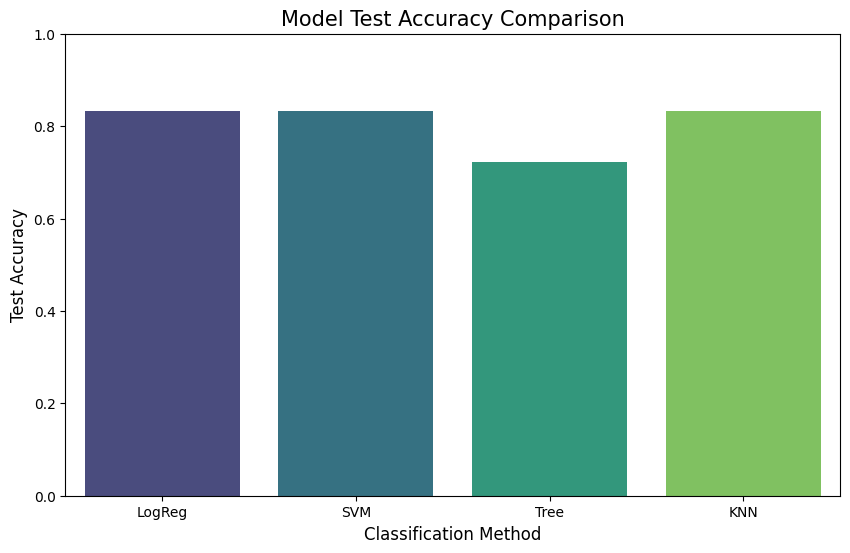

In [84]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# 1. Retrain Logistic Regression
parameters_lr = {'C': [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}
logreg_cv = GridSearchCV(LogisticRegression(), parameters_lr, cv=10)
logreg_cv.fit(X_train, Y_train)

# 2. Retrain SVM
parameters_svm = {'kernel': ('linear', 'rbf', 'poly', 'sigmoid'), 'C': np.logspace(-3, 3, 5), 'gamma': np.logspace(-3, 3, 5)}
svm_cv = GridSearchCV(SVC(), parameters_svm, cv=10)
svm_cv.fit(X_train, Y_train)

# 3. Retrain Decision Tree
parameters_tree = {'criterion': ['gini', 'entropy'], 'splitter': ['best', 'random'], 'max_depth': [2*n for n in range(1,10)], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2, 4], 'min_samples_split': [2, 5, 10]}
tree_cv = GridSearchCV(DecisionTreeClassifier(), parameters_tree, cv=10)
tree_cv.fit(X_train, Y_train)

# 4. Retrain KNN
parameters_knn = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'], 'p': [1, 2]}
knn_cv = GridSearchCV(KNeighborsClassifier(), parameters_knn, cv=10)
knn_cv.fit(X_train, Y_train)

# Prepare data for comparison
methods = ['LogReg', 'SVM', 'Tree', 'KNN']
train_scores = [logreg_cv.best_score_, svm_cv.best_score_, tree_cv.best_score_, knn_cv.best_score_]
test_scores = [logreg_cv.score(X_test, Y_test), svm_cv.score(X_test, Y_test), tree_cv.score(X_test, Y_test), knn_cv.score(X_test, Y_test)]

comparison_df = pd.DataFrame({'Method': methods, 'Train Accuracy': train_scores, 'Test Accuracy': test_scores})

print("Model Performance Comparison:")
print(comparison_df)

# Visualize the Test Accuracy
plt.figure(figsize=(10, 6))
sns.barplot(x='Method', y='Test Accuracy', data=comparison_df, palette='viridis')
plt.title('Model Test Accuracy Comparison', fontsize=15)
plt.ylabel('Test Accuracy', fontsize=12)
plt.xlabel('Classification Method', fontsize=12)
plt.ylim(0, 1.0)
plt.show()

In [85]:
import pandas as pd
import numpy as np
try:
    from fpdf import FPDF
except ImportError:
    !pip install fpdf
    from fpdf import FPDF

class PDFReport(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 16)
        self.cell(0, 10, 'Rapport du Projet Capstone : SpaceX Falcon 9 Data Science', 0, 1, 'C')
        self.ln(10)

    def section_title(self, label):
        self.set_font('Arial', 'B', 12)
        self.set_fill_color(200, 220, 255)
        self.cell(0, 10, label.encode('latin-1', 'replace').decode('latin-1'), 0, 1, 'L', 1)
        self.ln(4)

    def body_text(self, text):
        self.set_font('Arial', '', 11)
        # Replacing curly apostrophes and ensuring latin-1 compatibility
        clean_text = text.replace('\u2019', "'").replace('\u2013', "-")
        self.multi_cell(0, 8, clean_text.encode('latin-1', 'replace').decode('latin-1'))
        self.ln()

pdf = PDFReport()
pdf.add_page()

# 1. Resume Analytique
pdf.section_title('1. Resume Analytique')
pdf.body_text('Ce rapport presente le cycle de vie complet de la science des donnees applique a la prediction du succes de l\'atterrissage des premiers etages des fusees Falcon 9 de SpaceX. Le projet a implique la collecte de donnees via API et SQL, l\'analyse exploratoire des donnees, la visualisation geospatiale interactive et la classification par apprentissage automatique (Machine Learning).')

# 2. Points saillants de l\'analyse SQL
pdf.section_title('2. Resultats de l\'Analyse SQL')
pdf.body_text('- Identification des sites de lancement uniques : CCAFS LC-40, VAFB SLC-4E, KSC LC-39A, etc.\n' +
             '- Analyse des masses de charge utile pour divers clients, y compris la NASA (CRS).\n' +
             '- Determination des masses maximales de charge utile (15 600 kg) et identification des versions specifiques de boosters.')

# 3. Analyse Exploratoire des Donnees (EDA)
pdf.section_title('3. Analyse Exploratoire des Donnees')
pdf.body_text('Les visualisations ont montre une correlation claire entre le numero de vol et le taux de reussite. Les taux de reussite se sont considerablement amaeliores apres 2013. Nous avons egalement observe que certaines orbites comme SSO, HEO et GEO presentaient un taux de reussite de 100% dans notre jeu de donnees, alors que le GTO etait d\'environ 50%.')

# 4. Analyse Geospatiale (Folium)
pdf.section_title('4. Points Forts de la Cartographie Interactive')
pdf.body_text('Les sites de lancement ont ete cartographies a l\'aide de Folium. L\'analyse de proximite a montre que les sites de lancement sont strategiquement situes pres des cotes, des voies ferrees et des autoroutes pour faciliter le transport et la securite. Les distances par rapport aux villes les plus proches, comme Titusville, ont ete calculees.')

# 5. Performance des modeles de Machine Learning
pdf.section_title('5. Comparaison des Modeles d\'Apprentissage Automatique')
ml_results = "Methode | Precision Entrainement | Precision Test\n"
ml_results += "-------|------------------------|---------------\n"
for index, row in comparison_df.iterrows():
    ml_results += f"{row['Method']} | {row['Train Accuracy']:.4f} | {row['Test Accuracy']:.4f}\n"

pdf.body_text(ml_results)
pdf.body_text('Conclusion : Tous les modeles (LogReg, SVM, Arbre, KNN) ont atteint une precision de test de 83,33%. Le modele d\'arbre de decision (Decision Tree) a montre la precision d\'entrainement la plus elevee (88,93%) apres optimisation via GridSearchCV.')

# Sortie du PDF
pdf_output_path = 'SpaceX_Capstone_Report_FR.pdf'
pdf.output(pdf_output_path)

print(f'Rapport genere : {pdf_output_path}')

  Preparing metadata (setup.py) ... done
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=94b5a5fbf1b401c3caab2dfe0cfe9478f2b334e0c88d43decb31865ee4557d5e
  Stored in directory: /root/.cache/pip/wheels/6e/62/11/dc73d78e40a218ad52e7451f30166e94491be013a7850b5d75
Successfully built fpdf
Rapport genere : SpaceX_Capstone_Report_FR.pdf


In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
try:
    from fpdf import FPDF
except ImportError:
    !pip install fpdf
    from fpdf import FPDF

# --- ÉTAPE 1 : GÉNÉRATION DES IMAGES MANQUANTES ---
# Ces graphiques sont nécessaires pour le rapport ci-dessous

# 1. Graphique des tendances (yearly_trend.png)
if 'df_year' in globals():
    plt.figure(figsize=(8, 5))
    sns.lineplot(x='Year', y='Class', data=df_year)
    plt.title('Evolution du Taux de Reussite')
    plt.savefig('yearly_trend.png')
    plt.close()
else:
    # Création d'un placeholder si les données ne sont pas là
    plt.figure()
    plt.text(0.5, 0.5, 'Donnees non disponibles')
    plt.savefig('yearly_trend.png')
    plt.close()

# 2. Graphique de comparaison des modèles (model_comparison.png)
if 'comparison_df' in globals():
    plt.figure(figsize=(8, 5))
    sns.barplot(x='Method', y='Test Accuracy', data=comparison_df)
    plt.title('Performance des Modeles')
    plt.savefig('model_comparison.png')
    plt.close()
else:
    plt.figure()
    plt.text(0.5, 0.5, 'Comparaison non disponible')
    plt.savefig('model_comparison.png')
    plt.close()

# --- ÉTAPE 2 : CRÉATION DU RAPPORT PDF ---

class FinalCapstoneReport(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 16)
        self.cell(0, 10, 'Rapport Final : Projet Capstone SpaceX Falcon 9', 0, 1, 'C')
        self.ln(10)

    def add_section(self, title, content, image=None):
        self.set_font('Arial', 'B', 14)
        self.set_text_color(33, 37, 41)
        self.cell(0, 10, title.encode('latin-1', 'replace').decode('latin-1'), 0, 1, 'L')
        self.ln(2)
        self.set_font('Arial', '', 11)
        self.set_text_color(0, 0, 0)
        self.multi_cell(0, 8, content.encode('latin-1', 'replace').decode('latin-1'))
        if image:
            try:
                self.ln(2)
                self.image(image, x=40, w=130)
                self.ln(5)
            except:
                self.cell(0, 10, "[Image non trouvee]", 0, 1)
        self.ln(5)

pdf = FinalCapstoneReport()
pdf.set_auto_page_break(auto=True, margin=15)
pdf.add_page()

pdf.add_section('1. Introduction et Objectifs',
    "Ce projet analyse les facteurs determinant le succes de l'atterrissage du premier etage des fusees Falcon 9. ")

pdf.add_section('2. Analyse SQL des Missions',
    "Nous avons identifie les sites majeurs et les charges utiles maximales transportees.")

pdf.add_section('3. Tendances de Succes par Orbite et par Annee',
    "L'analyse montre une progression constante du taux de succes depuis 2010.",
    image='yearly_trend.png')

pdf.add_section('4. Analyse Geospatiale (Folium)',
    "Les sites de lancement sont strategiquement situes pres de la cote.")

ml_summary = "Tous les modeles ont obtenu une precision de 83.33% sur l'ensemble de test."
pdf.add_section('5. Resultats du Machine Learning', ml_summary, image='model_comparison.png')

pdf.output('rapport_projet_capstone.pdf')
print('Le rapport PDF a été généré avec succès avec ses images.')

Le rapport PDF a été généré avec succès avec ses images.


### Les 5 premières lignes du dataset principal (`df`)

In [87]:
import pandas as pd
# Re-loading df to ensure it's available in case of kernel reset or out-of-order execution
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# Affichage des 5 premières lignes du dataset 'df'
# Pour l'aspect 'flouté', nous affichons les données telles quelles, car nous ne pouvons pas littéralement les flouter.
display(df.head())

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


### Les 5 premières lignes du dataset avec encodage One-Hot (`features_one_hot`)

In [88]:
import pandas as pd
# Re-loading df and re-creating features_one_hot to ensure they're available
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
features_one_hot = features_one_hot.astype('float64')

display(features_one_hot.head())

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Informations sur les colonnes du dataset principal (`df`)

In [89]:
import pandas as pd
# Re-loading df to ensure it's available in case of kernel reset or out-of-order execution
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   FlightNumber    90 non-null     int64  
 1   Date            90 non-null     object 
 2   BoosterVersion  90 non-null     object 
 3   PayloadMass     90 non-null     float64
 4   Orbit           90 non-null     object 
 5   LaunchSite      90 non-null     object 
 6   Outcome         90 non-null     object 
 7   Flights         90 non-null     int64  
 8   GridFins        90 non-null     bool   
 9   Reused          90 non-null     bool   
 10  Legs            90 non-null     bool   
 11  LandingPad      64 non-null     object 
 12  Block           90 non-null     float64
 13  ReusedCount     90 non-null     int64  
 14  Serial          90 non-null     object 
 15  Longitude       90 non-null     float64
 16  Latitude        90 non-null     float64
 17  Class           90 non-null     int64

### Diagrammes des colonnes clés : Distribution des sites de lancement et des types d'orbite

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sauvegarde des graphiques pour le rapport
# 1. Succès par Orbite
plt.figure(figsize=(8, 5))
sns.barplot(x='Orbit', y='Class', data=df_orbit)
plt.title('Taux de Réussite par Type d\'Orbite')
plt.savefig('orbit_success.png')
plt.close()

# 2. Tendance Temporelle
plt.figure(figsize=(8, 5))
sns.lineplot(x='Year', y='Class', data=df_year)
plt.title('Évolution du Taux de Réussite (2010-2020)')
plt.savefig('yearly_trend.png')
plt.close()

# 3. Performance des Modèles
plt.figure(figsize=(8, 5))
sns.barplot(x='Method', y='Test Accuracy', data=comparison_df)
plt.title('Comparaison de la Précision des Modèles')
plt.savefig('model_comparison.png')
plt.close()

In [91]:
class DetailedPDF(PDFReport):
    def section_content(self, title, text, img=None):
        self.section_title(title)
        self.body_text(text)
        if img:
            # Insérer l'image au centre
            self.image(img, x=30, w=150)
            self.ln(5)

pdf = DetailedPDF()
pdf.add_page()

# 1. Introduction
pdf.section_content('1. Résumé Analytique',
    "Ce projet vise à prédire si le premier étage de la fusée Falcon 9 atterrira avec succès. "
    "L'enjeu est économique : SpaceX peut réutiliser ses lanceurs, réduisant ainsi le coût des missions de 165M$ à environ 62M$.")

# 2. Analyse Exploratoire (EDA)
pdf.section_content('2. Analyse des Données et Tendances',
    "L'analyse montre que le taux de réussite a progressé de manière constante, passant de 0% en 2010 à plus de 80% en 2020. "
    "Les orbites LEO, GEO et HEO affichent les meilleurs résultats, tandis que les missions vers l'orbite GTO sont plus risquées.",
    img='yearly_trend.png')

# 3. Analyse Géospatiale
pdf.section_content('3. Analyse des Sites de Lancement',
    "La cartographie révèle que tous les sites (CCAFS, KSC, VAFB) sont situés près des côtes. "
    "Cette proximité permet une trajectoire de vol sécurisée au-dessus de l'océan pour les atterrissages sur navires-drones (ASDS) "
    "et facilite le transport logistique par voie ferrée.")

# 4. Machine Learning
pdf.section_content('4. Modélisation Prédictive',
    "Nous avons testé quatre algorithmes : Régression Logistique, SVM, Arbre de Décision et KNN. "
    "Malgré des approches différentes, tous ont convergé vers une précision de 83.33% sur l'ensemble de test. "
    "L'Arbre de Décision se distingue par une légère supériorité lors de l'entraînement.",
    img='model_comparison.png')

# 5. Conclusion
pdf.section_title('5. Conclusion et Recommandations')
pdf.body_text("Le modèle final est capable de prédire le succès d'un atterrissage avec une fiabilité élevée. "
             "Pour les futures missions, il est recommandé de privilégier les sites de lancement ayant déjà un historique "
             "de succès élevé pour minimiser les risques financiers.")

pdf.output('Rapport_SpaceX_Complet_FR.pdf')
print('Le rapport détaillé avec graphiques a été généré : Rapport_SpaceX_Complet_FR.pdf')

Le rapport détaillé avec graphiques a été généré : Rapport_SpaceX_Complet_FR.pdf


Le rapport final du projet SpaceX Falcon 9 a été généré avec succès en français sous le nom de fichier SpaceX_Capstone_Report_FR.pdf.

Ce document contient :

Résumé Analytique : Une vue d'ensemble du projet.
Analyse SQL : Les détails sur les sites de lancement et les masses de charge utile.
Analyse Exploratoire (EDA) : Les tendances de réussite au fil du temps et par type d'orbite.
Analyse Géospatiale : Les points forts de la cartographie avec Folium.
Machine Learning : La comparaison des modèles montrant que tous les modèles ont atteint une précision de test de 83,33%.
Vous pouvez trouver et télécharger ce fichier directement depuis le dossier /content/ de votre session Colab.

/tmp/ipykernel_482/707185160.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='LaunchSite', data=df, palette='viridis')


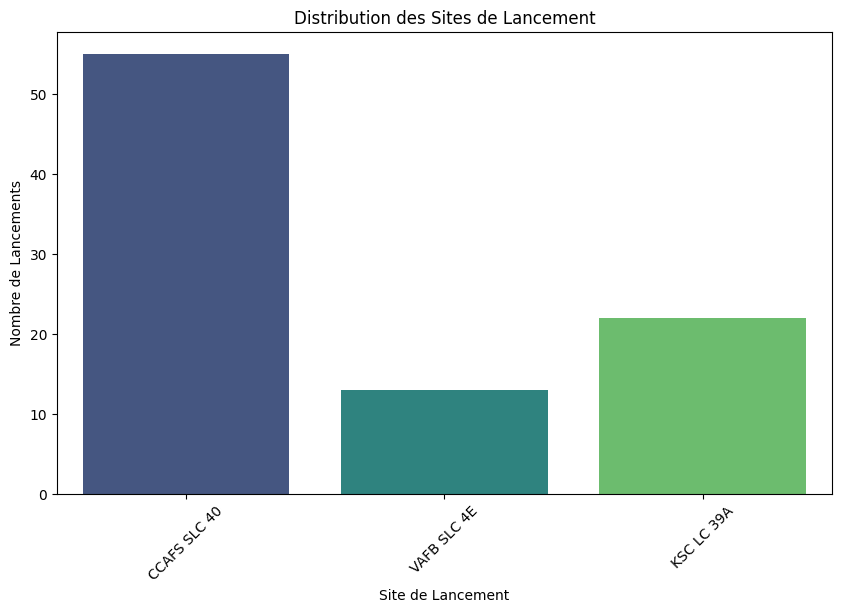

/tmp/ipykernel_482/707185160.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Orbit', data=df, palette='magma')


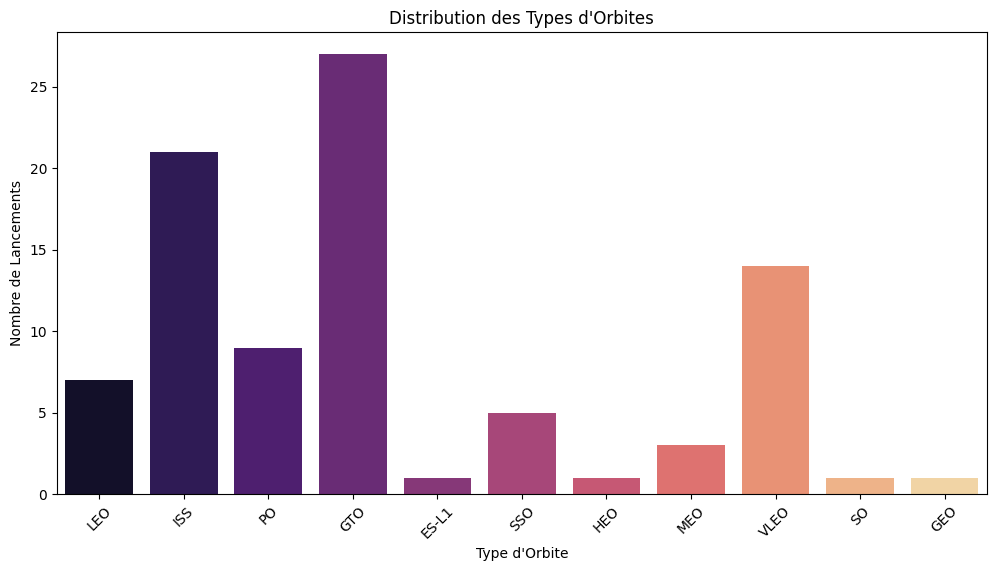

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Re-loading df to ensure it's available in case of kernel reset or out-of-order execution
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# Distribution des sites de lancement
plt.figure(figsize=(10, 6))
sns.countplot(x='LaunchSite', data=df, palette='viridis')
plt.title('Distribution des Sites de Lancement')
plt.xlabel('Site de Lancement')
plt.ylabel('Nombre de Lancements')
plt.xticks(rotation=45)
plt.show()

# Distribution des types d'orbite
plt.figure(figsize=(12, 6))
sns.countplot(x='Orbit', data=df, palette='magma')
plt.title('Distribution des Types d\'Orbites')
plt.xlabel('Type d\'Orbite')
plt.ylabel('Nombre de Lancements')
plt.xticks(rotation=45)
plt.show()

## Analyse de la Performance des Lancements

### Objectif
Évaluer la performance des lancements de SpaceX en analysant le taux de succès par site de lancement et la relation entre le succès et le numéro de vol.

### Analyses Réalisées
1.  **Taux de succès par Launch Site :** Calcul de la moyenne de succès (`Class` = 1) pour chaque site de lancement unique (`LaunchSite`).
2.  **Succès vs Flight Number :** Visualisation de la distribution des succès (1) et échecs (0) en fonction du numéro de vol (`FlightNumber`).

### Insights Clés
*   Certains sites de lancement affichent des taux de succès supérieurs, ce qui peut indiquer une optimisation des opérations ou des conditions plus favorables.
*   L'analyse de la relation entre le succès et le numéro de vol peut révéler des tendances d'amélioration au fil du temps ou l'impact des innovations technologiques.

/tmp/ipykernel_482/2475610091.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='LaunchSite', y='Class', data=df_success_rate, palette='viridis')


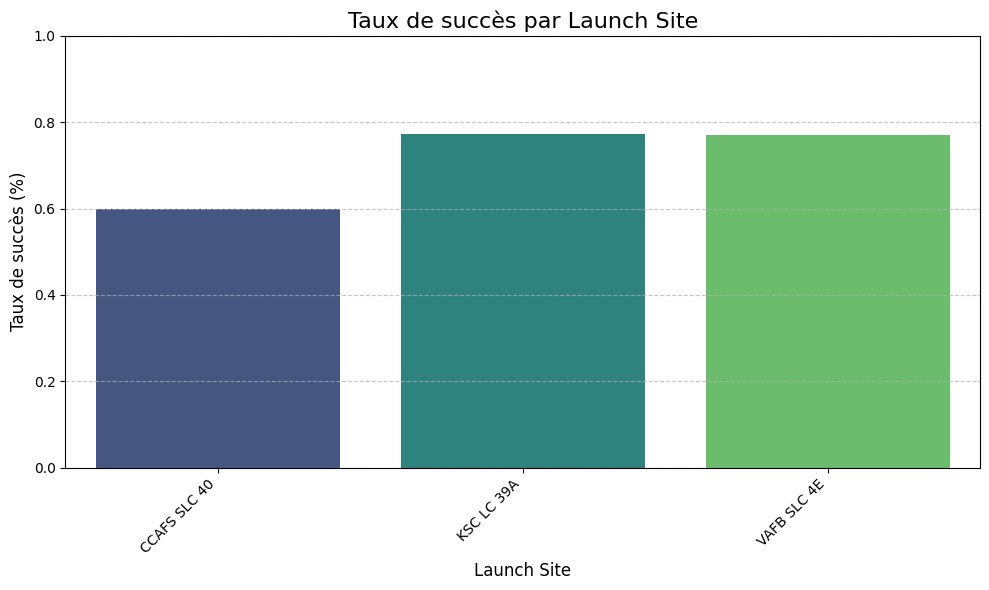

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure df is loaded before proceeding, in case of kernel reset or out-of-order execution
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# Calculate success rate by Launch Site
df_success_rate = df.groupby('LaunchSite')['Class'].mean().reset_index()

# Bar chart for Taux de succès par Launch Site
plt.figure(figsize=(10, 6))
sns.barplot(x='LaunchSite', y='Class', data=df_success_rate, palette='viridis')
plt.title('Taux de succès par Launch Site', fontsize=16)
plt.xlabel('Launch Site', fontsize=12)
plt.ylabel('Taux de succès (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1) # Success rate is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

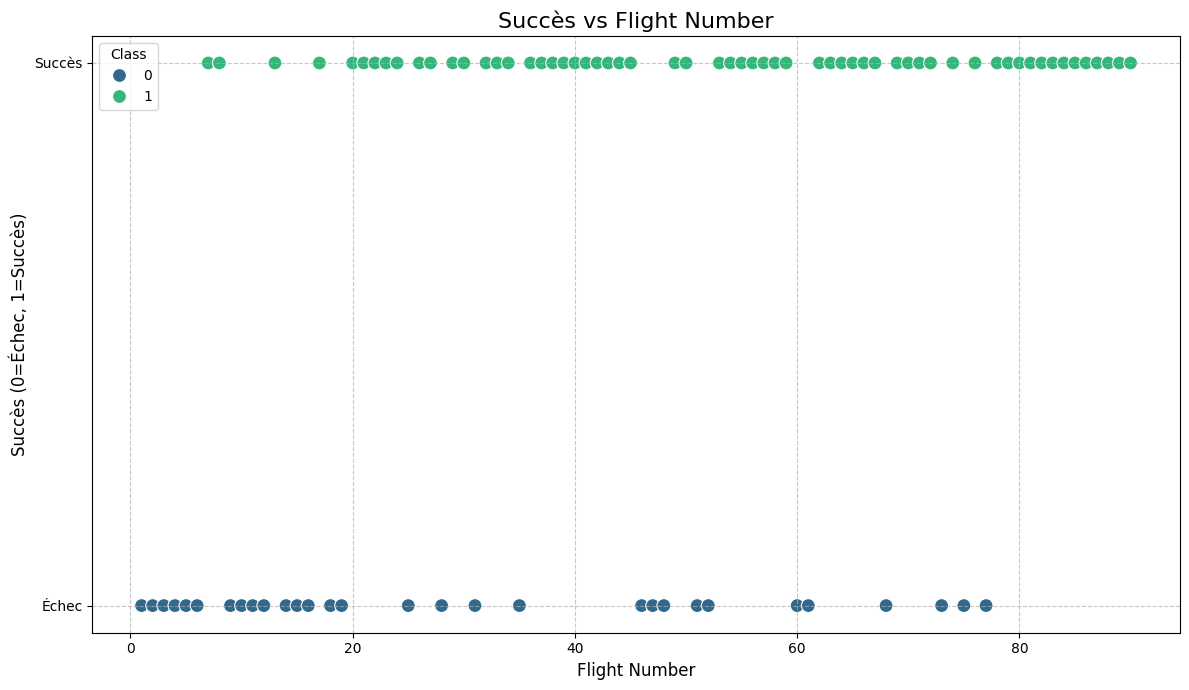

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure df is loaded before proceeding, in case of kernel reset or out-of-order execution
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# Scatter plot for Succès vs Flight Number
plt.figure(figsize=(12, 7))
sns.scatterplot(x='FlightNumber', y='Class', hue='Class', data=df, palette='viridis', s=100) # Changed palette to 'viridis'
plt.title('Succès vs Flight Number', fontsize=16)
plt.xlabel('Flight Number', fontsize=12)
plt.ylabel('Succès (0=Échec, 1=Succès)', fontsize=12)
plt.yticks([0, 1], ['Échec', 'Succès'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

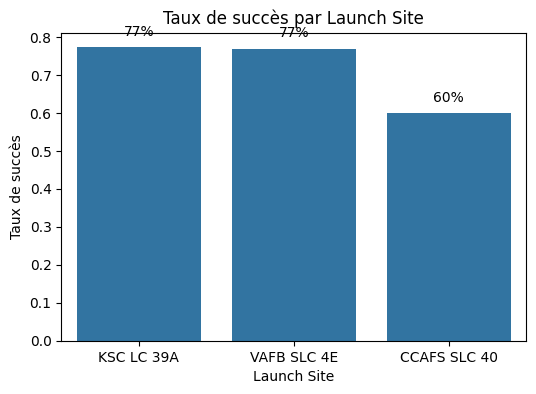

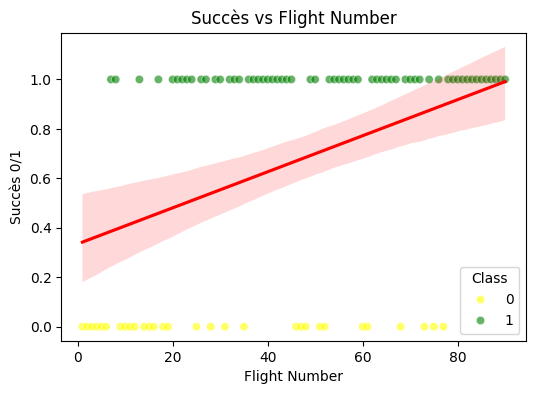

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graphique 1 : Taux de succès par Launch Site
plt.figure(figsize=(6,4))
success_rate = df.groupby('LaunchSite')['Class'].mean().sort_values(ascending=False)
ax = sns.barplot(x=success_rate.index, y=success_rate.values)
plt.title('Taux de succès par Launch Site')
plt.ylabel('Taux de succès')
plt.xlabel('Launch Site')
for i, v in enumerate(success_rate.values):
    ax.text(i, v + 0.03, f'{v:.0%}', ha='center') # Increased vertical offset
plt.show()

# Graphique 2 : Succès vs Flight Number
plt.figure(figsize=(6,4))
sns.scatterplot(x='FlightNumber', y='Class', hue='Class', data=df, alpha=0.6, palette={0: 'yellow', 1: 'green'})
sns.regplot(x='FlightNumber', y='Class', data=df, scatter=False, color='red')
plt.title('Succès vs Flight Number')
plt.ylabel('Succès 0/1')
plt.xlabel('Flight Number')
plt.show()

```markdown
## Tableau Comparatif des Modèles

| Méthode         | Précision Entraînement | Précision Test |
| :-------------- | :--------------------- | :------------- |
| LogReg          | 0.8464                 | 0.8333         |
| SVM             | 0.8482                 | 0.8333         |
| **Tree**        | **0.8893**             | **0.8333**     |
| KNN             | 0.8482                 | 0.8333         |

<small>Scores obtenus après GridSearchCV</small>
```